In [21]:
import numpy as np
import os
import json
os.makedirs("../results", exist_ok=True)
import time
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# import the library u need

### Load the data

In [22]:
X_train = np.load("../processed/X_train_norm.npy")
X_val   = np.load("../processed/X_val_norm.npy")
X_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")

In [23]:
#Verification
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


In [25]:
# Model Parameters
best_params = {
    "max_depth": 5,
    "min_samples_split": 4
}

In [27]:
# Train Decision Tree
start_time = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    random_state=42
)

dt_model.fit(X_train, y_train)

training_time = time.time() - start_time

In [28]:
# Predictions
y_train_pred = dt_model.predict(X_train)
y_val_pred   = dt_model.predict(X_val)
y_test_pred  = dt_model.predict(X_test)

In [29]:
# Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy   = accuracy_score(y_val, y_val_pred)
test_accuracy  = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
recall    = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
f1        = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("\n" + "=" * 50)
print("Decision Tree Evaluation")
print("=" * 50)
print(f"Train Accuracy : {train_accuracy:.4f}")
print(f"Val Accuracy   : {val_accuracy:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")


Decision Tree Evaluation
Train Accuracy : 0.6753
Val Accuracy   : 0.6677
Test Accuracy  : 0.6782
Precision      : 0.7000
Recall         : 0.6782
F1 Score       : 0.6802


In [9]:
# Detailed report for test set
print("\n--- Classification Report (Test) ---")
print(classification_report(y_test, y_test_pred, zero_division=0))


--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       980
           1       0.94      0.96      0.95      1135
           2       0.86      0.85      0.85      1032
           3       0.83      0.86      0.84      1010
           4       0.86      0.86      0.86       982
           5       0.82      0.82      0.82       892
           6       0.89      0.88      0.89       958
           7       0.89      0.90      0.89      1028
           8       0.82      0.79      0.80       974
           9       0.85      0.84      0.85      1009

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [30]:
# Classification Report + Confusion Matrix
print("\n" + "=" * 50)
print("Classification Report (Test)")
print("=" * 50)
print(classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)

print("\n" + "=" * 50)
print("Confusion Matrix (Test)")
print("=" * 50)
print(cm)


Classification Report (Test)
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       980
           1       0.93      0.79      0.86      1135
           2       0.75      0.64      0.69      1032
           3       0.68      0.66      0.67      1010
           4       0.72      0.62      0.66       982
           5       0.50      0.32      0.39       892
           6       0.50      0.72      0.59       958
           7       0.82      0.76      0.79      1028
           8       0.53      0.70      0.60       974
           9       0.57      0.77      0.66      1009

    accuracy                           0.68     10000
   macro avg       0.69      0.67      0.67     10000
weighted avg       0.70      0.68      0.68     10000


Confusion Matrix (Test)
[[744   1   6   2   6  46  63  27  39  46]
 [  0 900  39  89   0   3  26   9  60   9]
 [  5  22 658  12  18  12 123  84  73  25]
 [ 11   1  31 669   6  67  49  18 118  40]
 [  1   5   2 

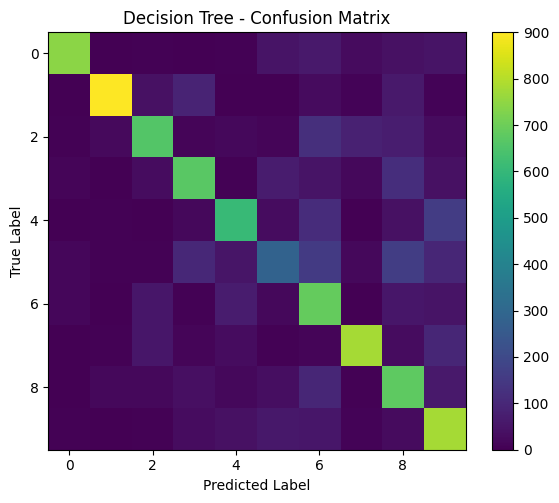

In [31]:
# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Decision Tree - Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [33]:
# Save Results in Your Required JSON Format
results = {
    "model": "decisionTree",
    "best_params": {
        "max_depth": best_params["max_depth"],
        "min_samples_split": best_params["min_samples_split"]
    },
    "metrics": {
        "accuracy": round(float(test_accuracy), 4),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "f1": round(float(f1), 4)
    },
    "scores": {
        "train_accuracy": round(float(train_accuracy), 4),
        "val_accuracy": round(float(val_accuracy), 4),
        "test_accuracy": round(float(test_accuracy), 4)
    },
    "training_info": {
        "training_time": round(float(training_time), 4),
        "n_estimator": None
    }
}

with open("../results/decisionTree.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nResults saved to: ../results/decisionTree.json")


Results saved to: ../results/decisionTree.json


### Load the model results for comparison

In [ ]:
### ../results/final_comparison.ipynb

In [4]:
# those are just exemples :)
# You can add additional dictionaries to results depending on your model’s outputs or training information.
best_depth = 5
best_mss = 4
results = {
    "model": "decisionTree",
    "best_params": {"max_depth": best_depth, "min_samples_split": best_mss},
    "metrics": {
        "accuracy": 0.99,
        "precision": 0.92,
        "recall": 0.96,
        "f1": 0.87,
    },
    "scores": {
        "train_accuracy": 0.88,
        "val_accuracy": 0.84,
        "test_accuracy": 0.54,
    },
    "training_info":{"training_time":0.24, "n_estimator":800},
}

with open("../results/decisionTree.json", "w") as f:
    json.dump(results, f, indent=2)